In [1]:
import sys
sys.path.append('../')

from dataclasses import dataclass, field
import torch
import random
import matplotlib.pyplot as plt

from modules import get_model
from dataset import UTSDataset

/home/svilhes/anaconda3/envs/anots/lib/python3.11/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


In [2]:
@dataclass
class NotebookConfig:
  
  normalization_strategy: str = "CausalRevIN" # the normalization strategy to use (RevIN or CausalRevIN)
  use_asinh: bool = True # whether to use asinh transformation in addition to the normalization strategy (should be True for CausalRevIN)
  device: str = "cuda" if torch.cuda.is_available() else "cpu" # the device to run the model on (cuda or cpu)

  context_size: int = 1024 # the length of the context signal
  forecast_horizon: int = 64 # the length of the forecast horizon
  context_plot_limit: int = 300 # not show the whole context but last 'context_plot_limit' observations (just for visualization)
  quantiles_forecasting: bool = True # whether to forecast quantiles in addition to the median
  kv_cache_if_possible: bool = True # whether to use kv cache if the model supports it (should be True for CausalRevIN)

  quantiles_dic: dict = field(default_factory=lambda: {
    0: "0.1", 
    1: "0.2",
    2: "0.3",
    3: "0.4",
    4: "0.5 (forecast)",
    5: "0.6",
    6: "0.7",
    7: "0.8",
    8: "0.9"
    })

config_nb = NotebookConfig()

In [3]:
dataset = UTSDataset(input_len=config_nb.context_size, output_len=config_nb.forecast_horizon, stride=128, flag="val", subset_name="UTSD-1G")

Resolving data files:   0%|          | 0/320 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Indexing dataset...


100%|██████████| 68679/68679 [00:27<00:00, 2499.15it/s]


In [4]:
model = get_model(revin_strategy=config_nb.normalization_strategy, use_asinh=config_nb.use_asinh, 
                  device=config_nb.device, kv_cache_if_possible=config_nb.kv_cache_if_possible, quantiles_forecasting=config_nb.quantiles_forecasting, seq_len=config_nb.context_size)

Using CausalRevIN with KV caching for inference.
Quantiles forecasting enabled: model will return all quantiles and compute SQL metric during evaluation.
The batch size will be multiplied by the number of quantiles. Make sure to adjust it accordingly to avoid OOM errors.


Text(0.5, 1.0, 'Forecasting with Normalizer Model')

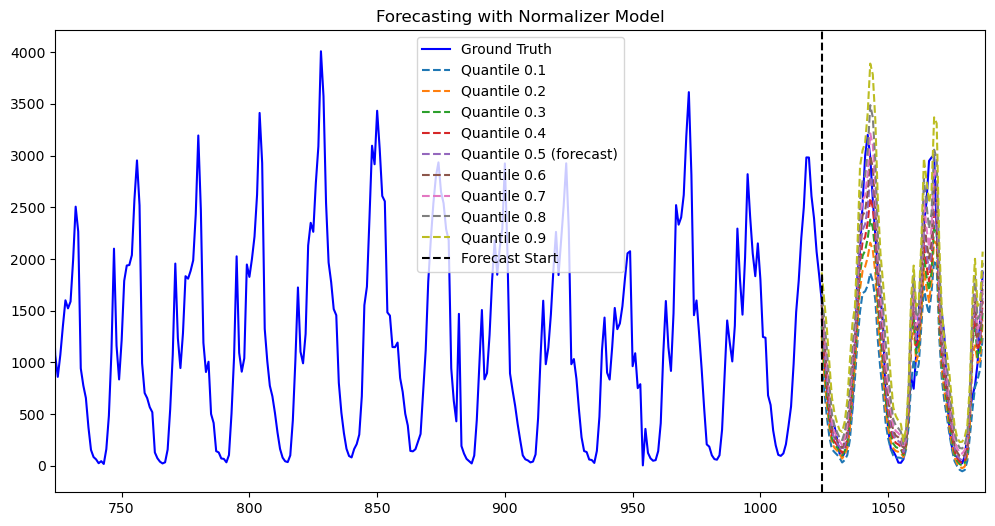

In [43]:
idx = random.randint(0, len(dataset))
context, target = dataset[idx]

xx = torch.cat([context, target], dim=0)

context_torch = context.unsqueeze(0).to(config_nb.device)

if config_nb.quantiles_forecasting:
    pred_median, pred_quantiles = model.forecast(context_torch, target_len=config_nb.forecast_horizon)
else:
    pred = model.forecast(context_torch, target_len=config_nb.forecast_horizon).squeeze(0).cpu().detach()



plt.figure(figsize=(12, 6))
plt.plot(xx.numpy(), label="Ground Truth", color="blue")

if config_nb.quantiles_forecasting:
    for i in range(pred_quantiles.shape[-1]):
        pred_q = pred_quantiles[:, :, i].squeeze(0).cpu().detach()
        plt.plot(range(len(context), len(context) + len(pred_q)), pred_q.numpy(), label=f"Quantile {config_nb.quantiles_dic[i]}", linestyle="--")
else:
    plt.plot(range(len(context), len(context) + len(pred)), pred.numpy(), label="Forecast", color="red")
    
plt.axvline(x=len(context), color="black", linestyle="--", label="Forecast Start")
plt.xlim(max(0, len(context) - config_nb.context_plot_limit), len(context) + config_nb.forecast_horizon)
plt.legend()
plt.title("Forecasting with Normalizer Model")